<a href="https://colab.research.google.com/github/TKhahahah/BSC_DPDM2025/blob/main/Final_DM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

In [59]:
df = pd.read_csv('/content/Final.csv')
df

,Day,Season,Humidity,Cloud_cover,Rainfall
0,1,rainy,high,heavy,rain
1,2,rainy,high,heavy,rain
2,3,rainy,high,moderate,rain
3,4,hot,low,clear,no rain
4,5,hot,low,clear,no rain
5,6,rainy,high,heavy,rain
6,7,rainy,-,heavy,rain
7,8,cool,medium,moderate,rain
8,9,hot,low,-,no rain
9,10,cool,medium,moderate,rain


# เตรียมข้อมูล

In [60]:
df.replace('-', np.nan, inplace=True)

humidity_mode = df['Humidity'].mode()[0]
cloud_cover_mode = df['Cloud_cover'].mode()[0]

df['Humidity'] = df['Humidity'].fillna(humidity_mode)
df['Cloud_cover'] = df['Cloud_cover'].fillna(cloud_cover_mode)
df

,Day,Season,Humidity,Cloud_cover,Rainfall
0,1,rainy,high,heavy,rain
1,2,rainy,high,heavy,rain
2,3,rainy,high,moderate,rain
3,4,hot,low,clear,no rain
4,5,hot,low,clear,no rain
5,6,rainy,high,heavy,rain
6,7,rainy,high,heavy,rain
7,8,cool,medium,moderate,rain
8,9,hot,low,heavy,no rain
9,10,cool,medium,moderate,rain


Encoding

In [61]:
# 1. Reload original data
df_clean = pd.read_csv('/content/Final.csv')
df_clean.replace('-', np.nan, inplace=True)

# 2. Impute missing values with mode
humidity_mode = df_clean['Humidity'].mode()[0]
cloud_cover_mode = df_clean['Cloud_cover'].mode()[0]
df_clean['Humidity'] = df_clean['Humidity'].fillna(humidity_mode)
df_clean['Cloud_cover'] = df_clean['Cloud_cover'].fillna(cloud_cover_mode)

# 3. Clean strings (strip whitespace)
for col in ['Season', 'Humidity', 'Cloud_cover', 'Rainfall']:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# 4. Apply Mapping
season_mapping = {'cool': 0, 'hot': 1, 'rainy': 2}
humidity_mapping = {'high': 0, 'low': 1, 'medium': 2}
cloud_cover_mapping = {'clear': 0, 'heavy': 1, 'moderate': 2}
rainfall_mapping = {'no rain': 0, 'rain': 1}

df_encoded_label = df_clean.copy()
df_encoded_label['Season'] = df_encoded_label['Season'].map(season_mapping)
df_encoded_label['Humidity'] = df_encoded_label['Humidity'].map(humidity_mapping)
df_encoded_label['Cloud_cover'] = df_encoded_label['Cloud_cover'].map(cloud_cover_mapping)
df_encoded_label['Rainfall'] = df_encoded_label['Rainfall'].map(rainfall_mapping)

df_encoded_label

,Day,Season,Humidity,Cloud_cover,Rainfall
0,1,2,0,1,1
1,2,2,0,1,1
2,3,2,0,2,1
3,4,1,1,0,0
4,5,1,1,0,0
5,6,2,0,1,1
6,7,2,0,1,1
7,8,0,2,2,1
8,9,1,1,1,0
9,10,0,2,2,1


In [62]:
display(df_encoded_label.describe())

# Also show value counts for the target variable 'Rainfall' to check balance
print('\nTarget variable (Rainfall) distribution:')
display(df_encoded_label['Rainfall'].value_counts())

,Day,Season,Humidity,Cloud_cover,Rainfall
count,13.00000,13.000000,13.000000,13.000000,13.000000
mean,7.00000,1.230769,0.615385,1.076923,0.692308
std,3.89444,0.832050,0.767948,0.759555,0.480384
min,1.00000,0.000000,0.000000,0.000000,0.000000
25%,4.00000,1.000000,0.000000,1.000000,0.000000
50%,7.00000,1.000000,0.000000,1.000000,1.000000
75%,10.00000,2.000000,1.000000,2.000000,1.000000
max,13.00000,2.000000,2.000000,2.000000,1.000000



Target variable (Rainfall) distribution:


,count
Rainfall,
1,9
0,4


# Train-validation-test split

In [63]:
# 2. แบ่งข้อมูล Train (Day 1-10) และ Test (Day 11-13)
# กรองข้อมูลตามค่าในคอลัมน์ 'Day'
train_df = df_encoded_label[df_encoded_label['Day'] <= 10].reset_index(drop=True)
test_df = df_encoded_label[df_encoded_label['Day'] > 10].reset_index(drop=True)

# แยก Features (X) และ Target (y)
# ปกติเราจะไม่ใช้ 'Day' เป็น Feature ในการเทรน
X_train = train_df.drop(columns=['Day', 'Rainfall'])
y_train = train_df['Rainfall']

X_test = test_df.drop(columns=['Day', 'Rainfall'])
y_test = test_df['Rainfall']

print(f"จำนวนข้อมูล Train: {len(X_train)} ชุด")
print(f"จำนวนข้อมูล Test: {len(X_test)} ชุด\n")

# 3. การทำ Cross Validation (K-Fold = 5) บนชุด Train เท่านั้น
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("--- ผลการแบ่ง K-Fold (5 Folds) บนชุด Train ---")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), 1):
    # ข้อมูลสำหรับ Train ในแต่ละ Fold
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    print(f"Fold {fold}:")
    print(f"  - Train data indices (ในชุด 10 วัน): {train_idx}")
    print(f"  - Validation data indices (ในชุด 10 วัน): {val_idx}")
    print(f"  - จำนวนข้อมูล Train: {len(X_fold_train)} | Validation: {len(X_fold_val)}")
    print("-" * 30)

# หลังจากการทำ CV และปรับจูนโมเดลเสร็จแล้ว
# คุณจึงจะนำโมเดลไปทดสอบครั้งสุดท้ายกับชุด test_df (Day 11-13)

จำนวนข้อมูล Train: 10 ชุด
จำนวนข้อมูล Test: 3 ชุด

--- ผลการแบ่ง K-Fold (5 Folds) บนชุด Train ---
Fold 1:
  - Train data indices (ในชุด 10 วัน): [0 2 3 4 5 6 7 9]
  - Validation data indices (ในชุด 10 วัน): [1 8]
  - จำนวนข้อมูล Train: 8 | Validation: 2
------------------------------
Fold 2:
  - Train data indices (ในชุด 10 วัน): [1 2 3 4 6 7 8 9]
  - Validation data indices (ในชุด 10 วัน): [0 5]
  - จำนวนข้อมูล Train: 8 | Validation: 2
------------------------------
Fold 3:
  - Train data indices (ในชุด 10 วัน): [0 1 3 4 5 6 8 9]
  - Validation data indices (ในชุด 10 วัน): [2 7]
  - จำนวนข้อมูล Train: 8 | Validation: 2
------------------------------
Fold 4:
  - Train data indices (ในชุด 10 วัน): [0 1 2 3 5 6 7 8]
  - Validation data indices (ในชุด 10 วัน): [4 9]
  - จำนวนข้อมูล Train: 8 | Validation: 2
------------------------------
Fold 5:
  - Train data indices (ในชุด 10 วัน): [0 1 2 4 5 7 8 9]
  - Validation data indices (ในชุด 10 วัน): [3 6]
  - จำนวนข้อมูล Train: 8 | Validation: 

# Model

In [64]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.tree import DecisionTreeClassifier
import numpy as np


## Decision tree 1

In [65]:
# 1. กำหนดโมเดลตามสเปกที่คุณต้องการ
dt_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=2,
    random_state=42,
    min_samples_split=2,
    criterion='gini'
)

# 2. ตั้งค่า K-Fold = 5 (สลับข้อมูลเพื่อความแม่นยำ)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. รัน Cross Validation บนชุด Train (Day 1-10)
# หมายเหตุ: X_train และ y_train คือข้อมูล 10 วันแรกที่แยกไว้ก่อนหน้านี้
cv_scores = cross_val_score(dt_model, X_train, y_train, cv=kf)

# 4. แสดงผลลัพธ์แต่ละ Fold
print("--- ผลลัพธ์ Cross Validation (5-Fold) ---")
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: Accuracy = {score:.2f}")

print(f"\nค่าเฉลี่ย Accuracy (Mean): {np.mean(cv_scores):.2f}")
print(f"ค่าความเบี่ยงเบน (Std Dev): {np.std(cv_scores):.2f}")

--- ผลลัพธ์ Cross Validation (5-Fold) ---
Fold 1: Accuracy = 0.50
Fold 2: Accuracy = 1.00
Fold 3: Accuracy = 0.50
Fold 4: Accuracy = 0.50
Fold 5: Accuracy = 1.00

ค่าเฉลี่ย Accuracy (Mean): 0.70
ค่าความเบี่ยงเบน (Std Dev): 0.24


In [76]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Define the Decision Tree classifier
dt = DecisionTreeClassifier(random_state=42)

# Define the parameter grid for Decision Tree
dt_param_grid = {
    'max_depth': [3],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [2],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2']
}

# Set up GridSearchCV for Decision Tree
dt_grid_search = GridSearchCV(dt, dt_param_grid, cv=kf, scoring='accuracy', n_jobs=-1, verbose=1)

# Train the Decision Tree model with grid search
dt_grid_search.fit(X_train, y_train)

print(f"Best parameters for Decision Tree: {dt_grid_search.best_params_}")
print(f"Best accuracy for Decision Tree: {dt_grid_search.best_score_:.4f}")

# 4. แสดงผลลัพธ์แต่ละ Fold ของพารามิเตอร์ที่ดีที่สุด
print("--- ผลลัพธ์ Cross Validation (5-Fold) ของ Best Model ---")
best_index = dt_grid_search.best_index_
for i in range(dt_grid_search.n_splits_):
    score = dt_grid_search.cv_results_[f'split{i}_test_score'][best_index]
    print(f"Fold {i+1}: Accuracy = {score:.2f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters for Decision Tree: {'criterion': 'gini', 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2}
Best accuracy for Decision Tree: 0.8000
--- ผลลัพธ์ Cross Validation (5-Fold) ของ Best Model ---
Fold 1: Accuracy = 1.00
Fold 2: Accuracy = 1.00
Fold 3: Accuracy = 0.50
Fold 4: Accuracy = 0.50
Fold 5: Accuracy = 1.00


In [67]:
from sklearn.metrics import accuracy_score

# Get the best model from the grid search
best_dt = dt_grid_search.best_estimator_

# Predict on the test set
y_pred_dt = best_dt.predict(X_test)

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_pred_dt)

print("--- Decision Tree Test Set Evaluation ---")
print(f"Predicted values (Days 11-13): {y_pred_dt}")
print(f"Actual values (Days 11-13):    {y_test.values}")
print(f"Test Accuracy: {test_accuracy:.4f}")

--- Decision Tree Test Set Evaluation ---
Predicted values (Days 11-13): [1 0 1]
Actual values (Days 11-13):    [1 0 1]
Test Accuracy: 1.0000


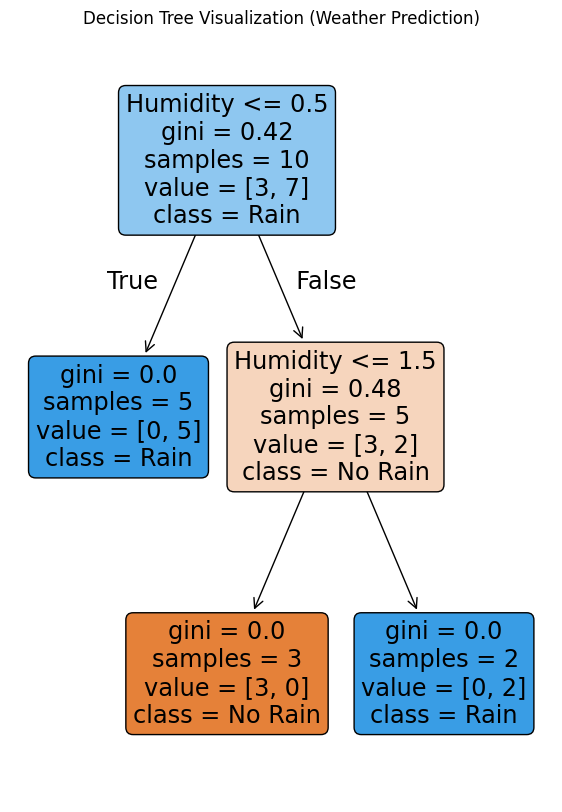

In [68]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# ใช้โมเดลที่ดีที่สุดจากการทำ Grid Search
best_dt = dt_grid_search.best_estimator_

plt.figure(figsize=(7, 10))
plot_tree(
    best_dt,
    feature_names=X_train.columns,
    class_names=['No Rain', 'Rain'],
    filled=True,
    rounded=True
)
plt.title('Decision Tree Visualization (Weather Prediction)')
plt.show()

over fitting

## KNN k=1

In [77]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Define the K-Nearest Neighbors classifier
knn = KNeighborsClassifier()

# Define the parameter grid for KNN
knn_param_grid = {
    'n_neighbors': [1],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Set up GridSearchCV for KNN
knn_grid_search = GridSearchCV(knn, knn_param_grid, cv=kf, scoring='accuracy', n_jobs=-1, verbose=1)

# Train the KNN model with grid search
knn_grid_search.fit(X_train, y_train)

print(f"Best parameters for KNN: {knn_grid_search.best_params_}")
print(f"Best accuracy for KNN: {knn_grid_search.best_score_:.4f}")

# 4. แสดงผลลัพธ์แต่ละ Fold ของพารามิเตอร์ที่ดีที่สุด
print("--- ผลลัพธ์ Cross Validation (5-Fold) ของ Best Model ---")
best_index = knn_grid_search.best_index_
for i in range(knn_grid_search.n_splits_):
    score = knn_grid_search.cv_results_[f'split{i}_test_score'][best_index]
    print(f"Fold {i+1}: Accuracy = {score:.2f}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best parameters for KNN: {'metric': 'euclidean', 'n_neighbors': 1, 'weights': 'uniform'}
Best accuracy for KNN: 1.0000
--- ผลลัพธ์ Cross Validation (5-Fold) ของ Best Model ---
Fold 1: Accuracy = 1.00
Fold 2: Accuracy = 1.00
Fold 3: Accuracy = 1.00
Fold 4: Accuracy = 1.00
Fold 5: Accuracy = 1.00


In [70]:
from sklearn.metrics import accuracy_score

# Get the best model from the KNN grid search
best_knn = knn_grid_search.best_estimator_

# Predict on the test set (Days 11-13)
y_pred_knn_test = best_knn.predict(X_test)

# Calculate accuracy
knn_test_accuracy = accuracy_score(y_test, y_pred_knn_test)

print("--- KNN Test Set Evaluation ---")
print(f"Predicted values (Days 11-13): {y_pred_knn_test}")
print(f"Actual values (Days 11-13):    {y_test.values}")
print(f"Test Accuracy: {knn_test_accuracy:.4f}")

--- KNN Test Set Evaluation ---
Predicted values (Days 11-13): [1 0 0]
Actual values (Days 11-13):    [1 0 1]
Test Accuracy: 0.6667


ผลการทดสอบโมเดล KNN กับชุดข้อมูลทดสอบ (วันที่ 11-13) ได้ค่าความแม่นยำ (Accuracy) อยู่ที่ประมาณ 66.67% ครับ โดยโมเดลทำนายผิดไป 1 วัน (วันที่ 13) ซึ่งทำนายว่าเป็น 'no rain' (0) แต่ค่าจริงคือ 'rain' (1) ครับ

under fitting